# 고객 충성도 분석(VIP)
- 실습06과 비슷한 문제로 가장 최근 구매와 직전 구매까지의 기간을 분석.
- 기간이 짧을 수록 충성도가 높은 고객으로 볼 수 있으며, 총 구매 순위와 같이 연관지어 분석 가능.

In [12]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [13]:
# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password= 'doruru0614!@#',  # 실제 비밀번호로 변경하세요
    database='classicmodels'
)

In [45]:
# 고객 충성도 분석 쿼리 실행
# 각 고객의 총 주문수(total_order)와 가장 최근의 주문 날짜(last_order_date)를 조회하는 쿼리
loyalty_query = """
select customerNumber,
       count(orderNumber) as total_order,
       max(orderDate) as last_order_date
from orders
group by customerNumber;
       
"""

In [46]:
# SQL 쿼리 실행 및 결과 DataFrame으로 변환
loyalty_df = pd.read_sql_query(loyalty_query, conn)

In [9]:
# 연결 종료
conn.close()

In [48]:
top_20_customers = loyalty_df.head(20)

In [49]:
top_20_customers

,customerNumber,total_order,last_order_date
0,103,3,2004-11-25
1,112,3,2004-11-29
2,114,5,2004-11-29
3,119,4,2005-05-31
4,121,4,2004-11-05
5,124,17,2005-05-29
6,128,4,2004-11-05
7,129,3,2004-11-18
8,131,4,2004-11-15
9,141,26,2005-05-31


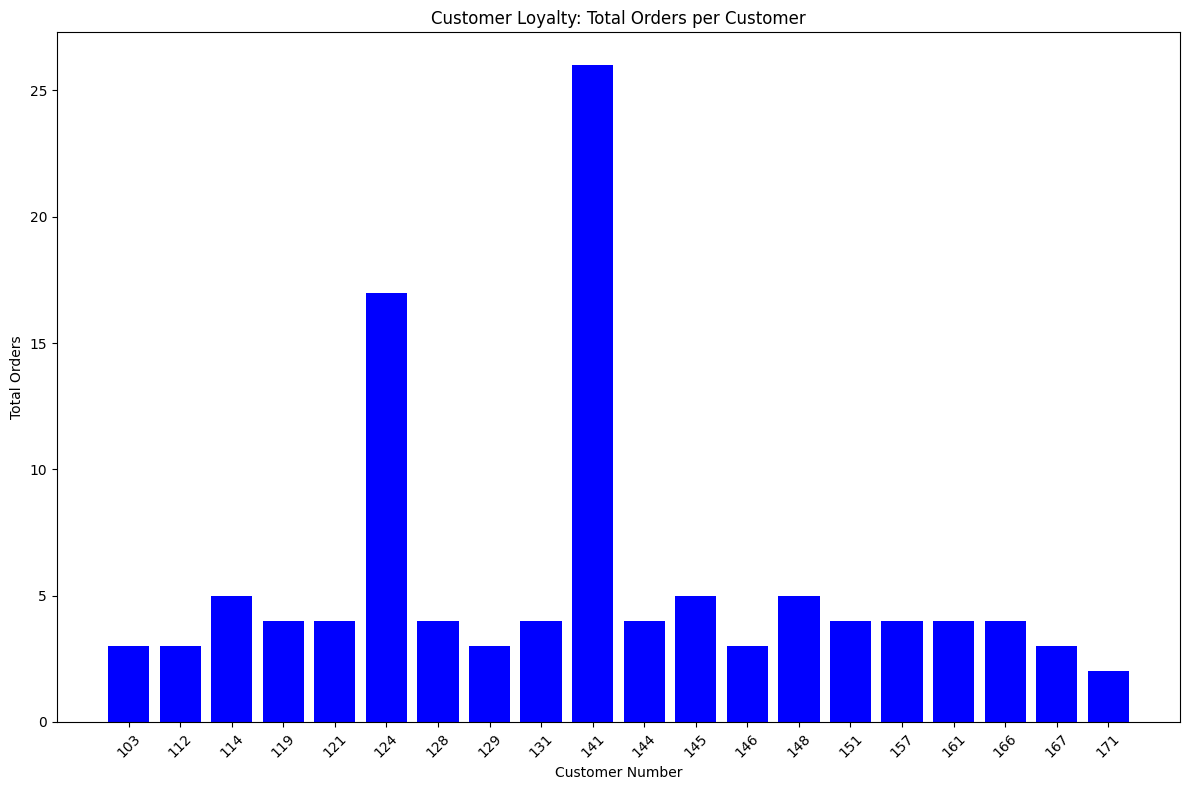

In [50]:
# 고객별 총 주문 수 시각화 (고객 번호 사용)
plt.figure(figsize=(12, 8))
plt.bar(top_20_customers['customerNumber'].astype(str), top_20_customers['total_order'], color='blue')
plt.xlabel('Customer Number')
plt.ylabel('Total Orders')
plt.title('Customer Loyalty: Total Orders per Customer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# 데이터셋 내의 최신 구매일을 기준으로 경과된 일수 계산
latest_order_date = loyalty_df['last_order_date'].max()
loyalty_df['days_since_last_order'] = (pd.to_datetime(latest_order_date) - pd.to_datetime(loyalty_df['last_order_date'])).dt.days

In [51]:
loyalty_df

,customerNumber,total_order,last_order_date
0,103,3,2004-11-25
1,112,3,2004-11-29
2,114,5,2004-11-29
3,119,4,2005-05-31
4,121,4,2004-11-05
...,...,...,...
93,486,3,2004-11-17
94,487,2,2004-02-10
95,489,2,2004-01-22
96,495,2,2004-04-26


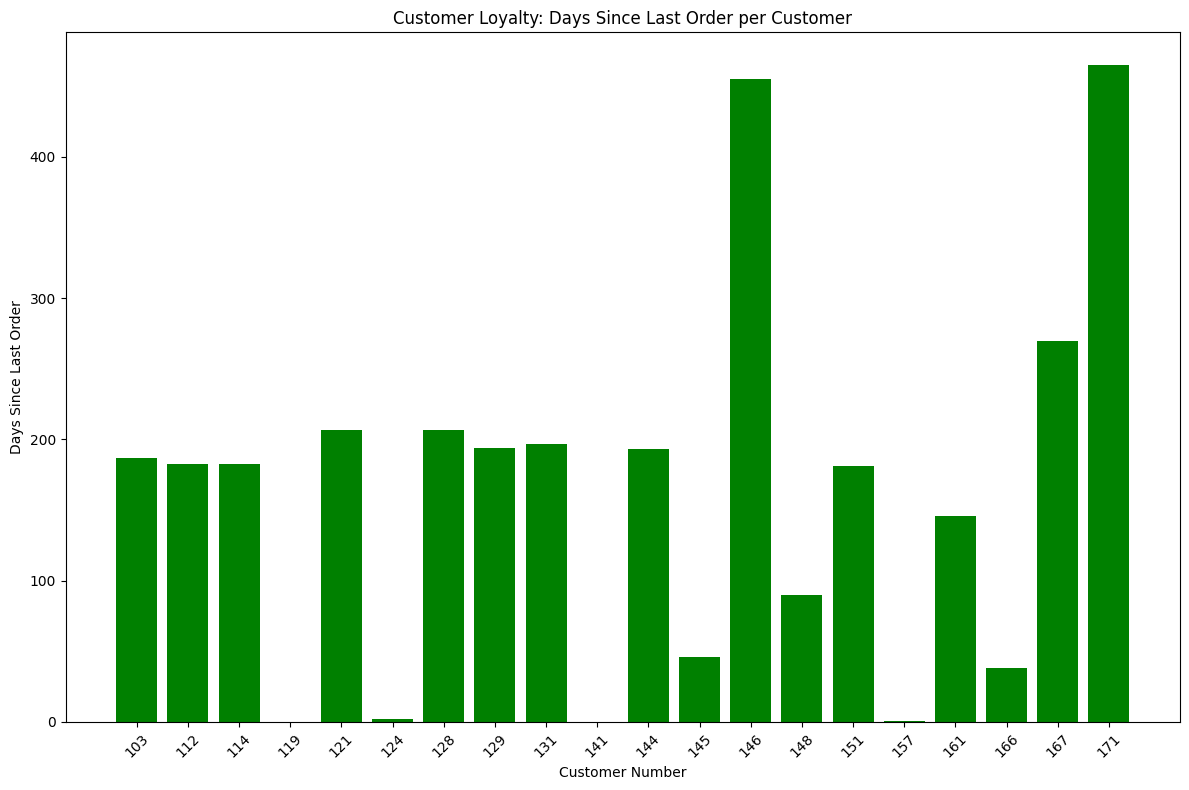

In [44]:
# 고객별 마지막 구매로부터 경과된 일수 시각화 (고객 번호 사용)
plt.figure(figsize=(12, 8))
plt.bar(top_20_customers['customerNumber'].astype(str), top_20_customers['days_since_last_order'], color='green')
plt.xlabel('Customer Number')
plt.ylabel('Days Since Last Order')
plt.title('Customer Loyalty: Days Since Last Order per Customer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 회사 입장에서 취할 수 있는 행동
- VIP 고객 프로그램 개발: 총 주문 수가 많은 상위 고객을 대상으로
VIP 고객 프로그램을 개발하여 이들의 충성도를 더욱 강화할 수
있음. 이러한 프로그램에는 특별 할인, 개인 맞춤형 서비스, 우선적
고객 지원 등이 포함될 수 있음.

- 재구매 유도 전략: 마지막 구매 이후 오랜 시간이 지난 고객을
대상으로 재구매를 유도하는 마케팅 캠페인을 실시할 수 있음.
이메일 마케팅, 리타겟팅 광고, 특별 프로모션 제공 등을 통해
이들을 다시 유치할 수 있음.

- 고객 피드백 수집 및 분석: 고객 충성도와 구매 행동에 대한 더 깊은
이해를 위해 고객 피드백을 수집하고 분석하는 것이 중요. 이를 통해
제품이나 서비스의 개선점을 찾고, 고객 만족도를 높일 수 있는
방안을 모색할 수 있음.

- 고객 세분화에 기반한 맞춤형 마케팅: 고객의 구매 패턴, 선호도,
마지막 구매 이후 경과된 시간 등 다양한 데이터를 기반으로 고객
세분화를 수행하고, 각 세그먼트별로 맞춤형 마케팅 전략을 수립할
수 있음.